## Web Scrapping

In [1]:
import numpy as np 
import pandas as pd
from bs4 import BeautifulSoup  
import requests
import time

 **Web scraping is simply crawling the html and javascript of a webpage to extract the
 details we want to use as data. The most complicated part of this is inspecting the
 webpage source code to determine what to grab and what to ignore.**

 
**In this demo I'll demonstrate how to create a dataset from the weekend performance
 page of Box Office Mojo, a great datasource for box office performance data. The
 associated dataset that is created and updated from this notebook can be found here:**

#### 1. Check if website allows scraping

 Take the root of the url, in this case https://www.boxofficemojo.com and add '/robots.txt'
 to the end. This will come up with a page that shows what type of web scraping is
 allowed or disallowed. Thankfully Box Office Mojo allows all.

#### 2. Setup Headers & URL

In [2]:
BASE_URL = "https://www.boxofficemojo.com/weekend/by-year/{}/"

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

#### 3. Helper Functions

In [3]:
def fetch_page(url):
    response = requests.get(url, headers=HEADERS)
    
    if response.status_code != 200:
        raise Exception(f"Failed to fetch {url}")
    
    return response.text


def parse_table(html, year):
    soup = BeautifulSoup(html, "html.parser")
    rows = soup.find_all("tr")
    
    data = []
    
    for row in rows:
        cols = row.find_all("td")
        
        if len(cols) == 0:
            continue
        
        try:
            data.append({
                "year": year,
                "date": cols[0].get_text(strip=True),
                "top10_gross": cols[1].get_text(strip=True),
                "top10_wow": cols[2].get_text(strip=True),
                "overall_gross": cols[3].get_text(strip=True),
                "overall_wow": cols[4].get_text(strip=True),
            })
        except:
            continue
    
    return data

#### 4. Data Cleaning Functions

In [4]:
def clean_money(x):
    if x:
        return int(x.replace("$", "").replace(",", ""))
    return None


def clean_percent(x):
    if not x or x.strip() in ["-", "—"]:
        return None
    try:
        return float(x.replace("%", "").replace("+", "").replace(",", ""))
    except:
        return None

#### 5. Scrape Data

In [5]:
all_data = []

start_year = 2020
end_year = 2023

for year in range(start_year, end_year + 1):
    print(f"Scraping {year}...")
    
    url = BASE_URL.format(year)
    html = fetch_page(url)
    
    year_data = parse_table(html, year)
    all_data.extend(year_data)
    
    time.sleep(1)  # polite scraping

print("Scraping completed!")

Scraping 2020...
Scraping 2021...
Scraping 2022...
Scraping 2023...
Scraping completed!


#### 6. Create DataFrame

In [6]:
df = pd.DataFrame(all_data)

df.head()

,year,date,top10_gross,top10_wow,overall_gross,overall_wow
0,2020,Dec 25-27COVID-19 Pandemic,"$23,992,583",+256.5%,"$24,529,617",+221.7%
1,2020,Dec 18-20COVID-19 Pandemic,"$6,729,235",+20.2%,"$7,625,545",+13.8%
2,2020,Dec 11-13COVID-19 Pandemic,"$5,596,422",-24.7%,"$6,701,727",-20.2%
3,2020,Dec 4-6COVID-19 PandemicPost-Thanksgiving,"$7,435,065",-43.8%,"$8,397,393",-40.7%
4,2020,Nov 27-29COVID-19 PandemicThanksgiving 3-Day,"$13,230,347",+145.8%,"$14,152,936",+120.9%


#### 7. Clean Data

In [7]:
df["top10_gross"] = df["top10_gross"].apply(clean_money)
df["overall_gross"] = df["overall_gross"].apply(clean_money)
df["top10_wow"] = df["top10_wow"].apply(clean_percent)
df["overall_wow"] = df["overall_wow"].apply(clean_percent)

df.head()

,year,date,top10_gross,top10_wow,overall_gross,overall_wow
0,2020,Dec 25-27COVID-19 Pandemic,23992583,256.5,24529617,221.7
1,2020,Dec 18-20COVID-19 Pandemic,6729235,20.2,7625545,13.8
2,2020,Dec 11-13COVID-19 Pandemic,5596422,-24.7,6701727,-20.2
3,2020,Dec 4-6COVID-19 PandemicPost-Thanksgiving,7435065,-43.8,8397393,-40.7
4,2020,Nov 27-29COVID-19 PandemicThanksgiving 3-Day,13230347,145.8,14152936,120.9


#### 8. Save Data

In [8]:
df.to_csv("box_office_data.csv", index=False)

print("Data saved successfully!")

Data saved successfully!


#### 9. Basic Analysis

<Axes: title={'center': 'Yearly Box Office Gross'}, xlabel='year'>

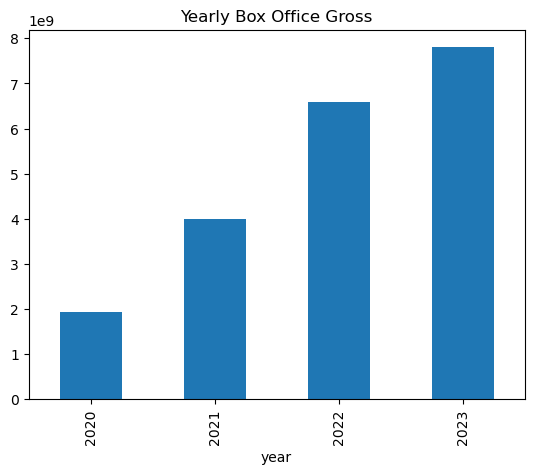

In [9]:
df.groupby("year")["overall_gross"].sum().plot(kind="bar", title="Yearly Box Office Gross")

#### 10. Top 5 Highest Grossing Weekends

In [10]:
top_weekends = df.sort_values(by="overall_gross", ascending=False).head(5)
top_weekends

,year,date,top10_gross,top10_wow,overall_gross,overall_wow
214,2023,Jul 21-23,307805201,129.4,310952297,121.4
62,2021,Dec 17-19,281737588,591.1,282972675,544.0
153,2022,Jul 8-10,237265821,25.9,238358815,25.5
231,2023,Apr 7-10Easter wknd,227011315,NaN,231916311,NaN
154,2022,Jul 1-4July 4th long wknd,221928586,NaN,223580059,NaN


#### 11. Trend Over Time

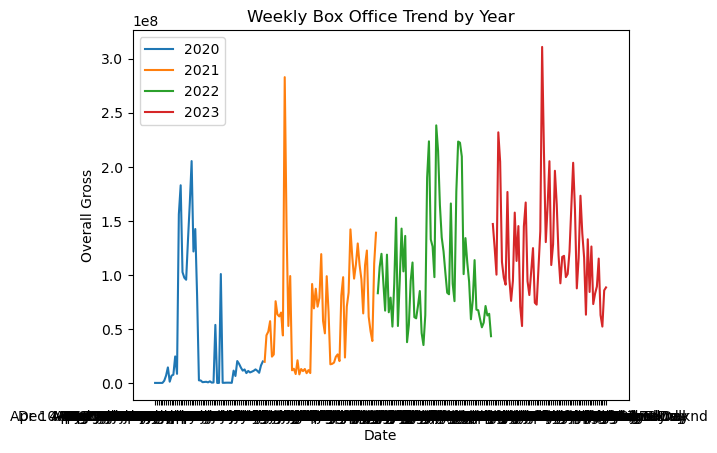

In [11]:
import matplotlib.pyplot as plt

for year, group in df.groupby("year"):
    group = group.sort_values("date")
    plt.plot(group["date"], group["overall_gross"], label=year)

plt.title("Weekly Box Office Trend by Year")
plt.xlabel("Date")
plt.ylabel("Overall Gross")
plt.legend()
plt.show()

#### 12. Average Weekly Growth

<Axes: title={'center': 'Average Weekly % Change per Year'}, xlabel='year'>

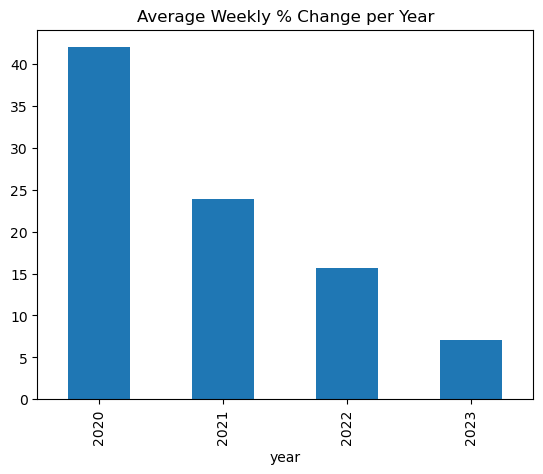

In [12]:
df.groupby("year")["overall_wow"].mean().plot(
    kind="bar",
    title="Average Weekly % Change per Year"
)